In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm  # Import tqdm for Jupyter notebooks

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Load the dataset with progress indication
print("Loading dataset...")
file_path = '/home/understressengineer/programming/SRM_PS1/processed_data/merged_data_20Hz.csv'
df = pd.read_csv(file_path)
print(f"Loaded {len(df)} records.")

# Basic dataset exploration
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset info:")
display(df.info())
print("\nSummary statistics:")
display(df.describe())
print("\nMissing values:")
display(df.isna().sum())
print("\nColumns in dataset:")
display(df.columns.tolist())

Loading dataset...
Loaded 394370 records.
Dataset shape: (394370, 13)

First 5 rows:


,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B,source_dataset
0,2025-02-10 01:04:09,Atul,101/102,Reverse,"0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,...","0.0,13.5,46.5,72.0,88.5,99.0,103.5,108.0,109.5...","0,5.8,5.2,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,85.5,88.5,97.5,102.0,106.5,109.5,111.0,111...",TWS,IRS,100,100.0,WR
1,2025-02-10 01:12:10,Atul,101/102,Normal,"0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,...","0.0,88.5,90.0,97.5,102.0,105.0,108.0,109.5,111...","0.0,4.4,5.2,4.2,3.5,2.9,2.5,2.2,2,1.8,1.7,1.7,...","0.0,24.0,54.0,78.0,91.5,99.0,105.0,108.0,109.5...",TWS,IRS,100,100.0,WR
2,2025-02-10 07:13:06,Atul,101/102,Reverse,"0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2....","0.0,25.5,55.5,78.0,91.5,100.5,105.0,108.0,109....","0,5.8,5.3,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,84.0,88.5,97.5,103.5,106.5,109.5,111.0,112...",TWS,IRS,100,100.0,WR
3,2025-02-10 08:00:53,Atul,101/102,Reverse,"0.0,4.5,4.7,3.9,3.2,2.7,2.4,2.1,2,1.9,1.9,1.9,...","0.0,37.5,66.0,84.0,96.0,102.0,106.5,109.5,111....","0,5.5,5.4,4.3,3.4,2.9,2.5,2.2,2,1.8,1.8,1.7,1....","0.0,87.0,87.0,96.0,102.0,106.5,108.0,111.0,111...",TWS,IRS,100,100.0,WR
4,2025-02-10 08:03:36,Atul,101/102,Normal,"0,5.1,5.1,4.1,3.4,2.9,2.5,2.2,2,1.9,1.8,1.8,1....","0.0,90.0,90.0,96.0,102.0,105.0,108.0,109.5,111...","0.0,3.5,5.5,4.4,3.6,3,2.6,2.2,2,1.8,1.7,1.7,1....","0.0,18.0,48.0,75.0,90.0,97.5,103.5,108.0,109.5...",TWS,IRS,100,100.0,WR



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394370 entries, 0 to 394369
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Time                394370 non-null  object 
 1   Site Name           394370 non-null  object 
 2   Point Machine Name  394370 non-null  object 
 3   Direction           394370 non-null  object 
 4   A Current           393925 non-null  object 
 5   A Voltage           393928 non-null  object 
 6   B Current           393686 non-null  object 
 7   B Voltage           393852 non-null  object 
 8   Type of A           394370 non-null  object 
 9   Type of B           336790 non-null  object 
 10  Polling of A        394370 non-null  int64  
 11  Polling of B        336790 non-null  float64
 12  source_dataset      394370 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 39.1+ MB


None


Summary statistics:


,Polling of A,Polling of B
count,394370.000000,336790.000000
mean,48.295459,48.059265
std,38.249280,38.176212
min,20.000000,20.000000
25%,20.000000,20.000000
50%,20.000000,20.000000
75%,100.000000,100.000000
max,100.000000,100.000000



Missing values:


Time                      0
Site Name                 0
Point Machine Name        0
Direction                 0
A Current               445
A Voltage               442
B Current               684
B Voltage               518
Type of A                 0
Type of B             57580
Polling of A              0
Polling of B          57580
source_dataset            0
dtype: int64


Columns in dataset:


['Time',
 'Site Name',
 'Point Machine Name',
 'Direction',
 'A Current',
 'A Voltage',
 'B Current',
 'B Voltage',
 'Type of A',
 'Type of B',
 'Polling of A',
 'Polling of B',
 'source_dataset']


===== Setting Up Point Machine Analysis =====
Using 'Point Machine Name' as point machine identifier with 159 unique machines
Analyzing point machine distribution by site...

Number of point machines per site:


Site Name
Ballabhgarh           34
Faridabad             34
Surat                 32
Dahanu Road           29
Asoati                21
Udhna                 19
Atul                  13
Bilimora              11
Vapi                  10
Karambeli             10
Bhestan                9
Faridabad New Town     9
Shaphale               8
Umargaon               7
Pardi                  7
Junction Cabin         6
Gholvad                6
Vedchha                6
Maroli                 4
Iriset                 3
Vaitarna               1
Name: Point Machine Name, dtype: int64

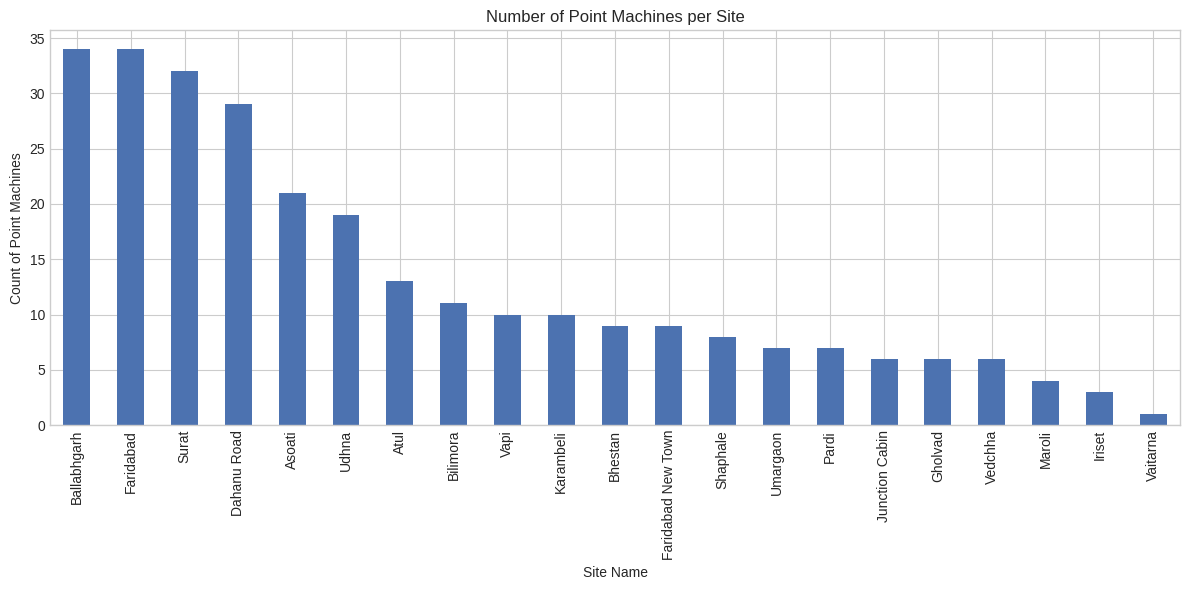

In [2]:
# Try to identify point machine ID column and prepare for analysis
print("\n===== Setting Up Point Machine Analysis =====")

# From the column examination, we know "Point Machine Name" is our identifier
point_id_col = 'Point Machine Name'
print(f"Using '{point_id_col}' as point machine identifier with {df[point_id_col].nunique()} unique machines")

# Check distribution of point machines by site
print("Analyzing point machine distribution by site...")
site_machine_counts = df.groupby('Site Name')[point_id_col].nunique().sort_values(ascending=False)
print("\nNumber of point machines per site:")
display(site_machine_counts)

# Visualize the distribution
plt.figure(figsize=(12, 6))
site_machine_counts.plot(kind='bar')
plt.title('Number of Point Machines per Site')
plt.xlabel('Site Name')
plt.ylabel('Count of Point Machines')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


===== Per-Point Machine Analysis =====
Counting records per point machine...

Record counts per point machine (top 10):


Point Machine Name
PT-117/118      28274
PT-101/102      19558
PT-105/106      15885
PT-103/104      13128
PT 141 - 142    12087
PT-119/120      11018
PT103/104       10669
PT115/116        9855
PT-109/110       8887
PT 135 - 136     8385
Name: count, dtype: int64

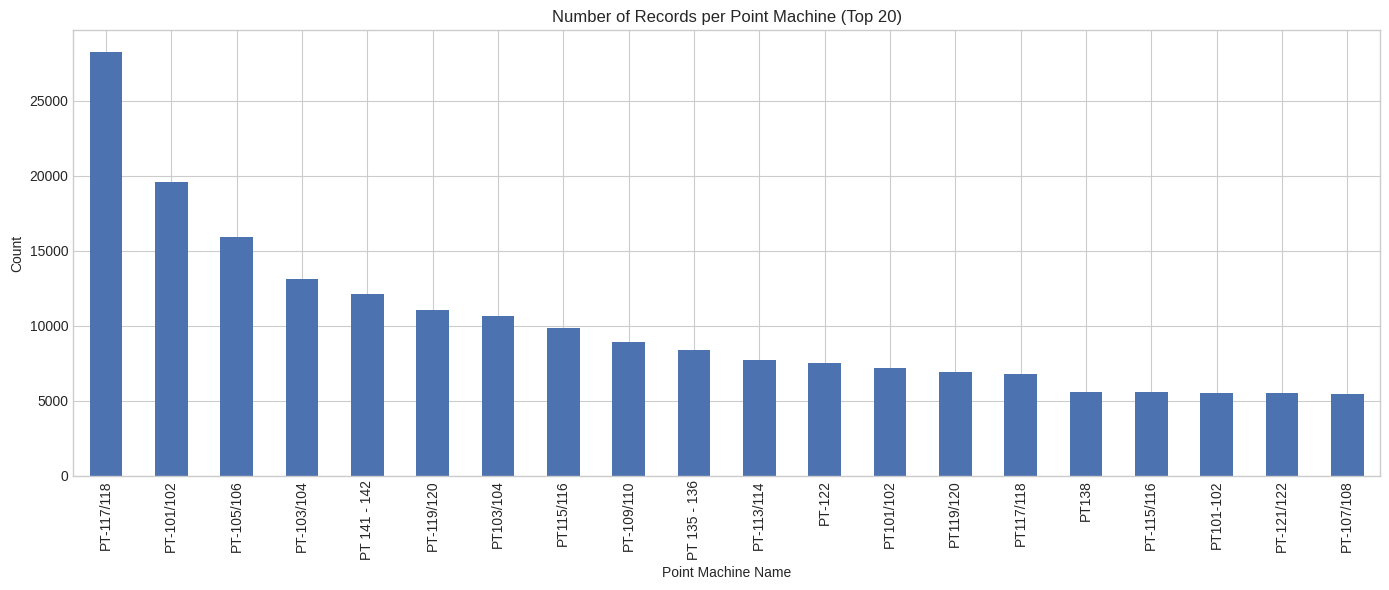


Analyzing direction distributions...

Direction distribution by point machine (first 10):


Direction,Normal,Reverse
Point Machine Name,,
101/102,0.488670,0.511330
127/128,0.467178,0.532822
129/130,0.467308,0.532692
131/132,0.501295,0.498705
133,0.495667,0.504333
135/136,0.491324,0.508676
137,0.485777,0.514223
141/142,0.442339,0.557661
145,0.481268,0.518732



Visualizing direction distribution for top 10 machines...


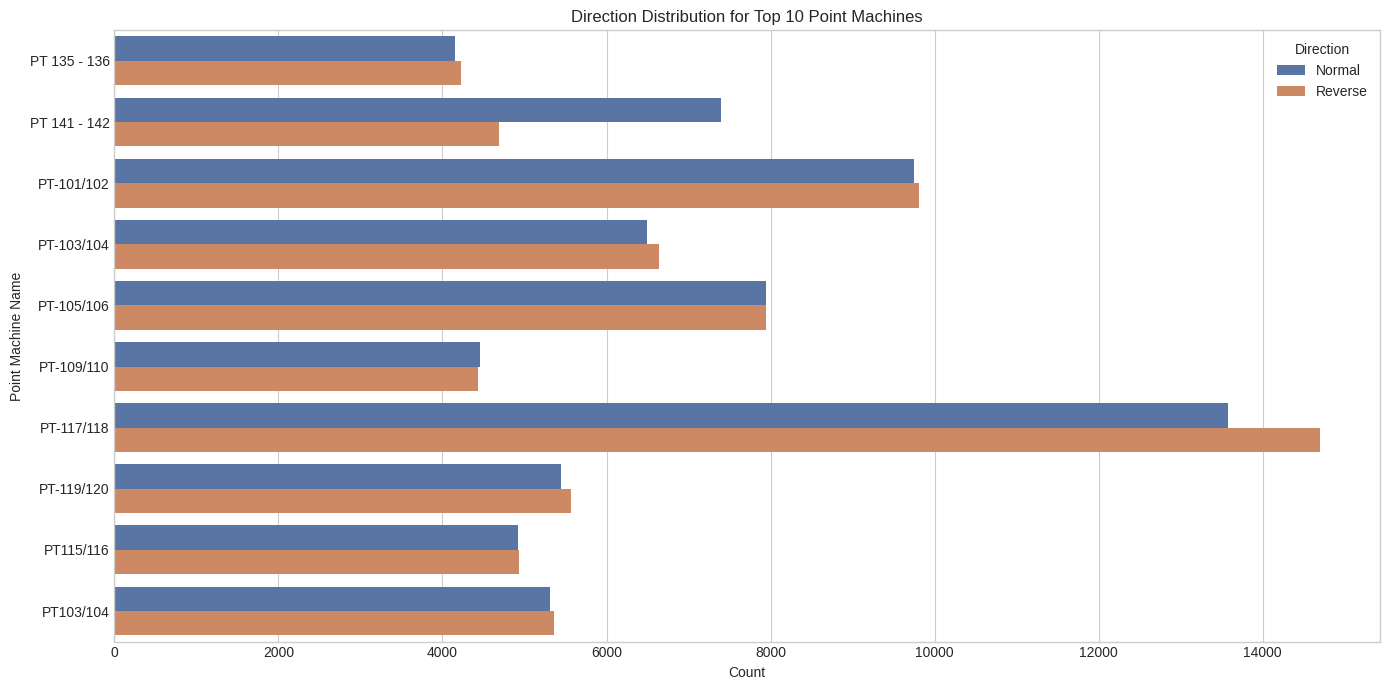


Analyzing machine types...

Distribution of point machine types:


,Type A,Type B
IRS,283124,172644
TWS,111246,164146


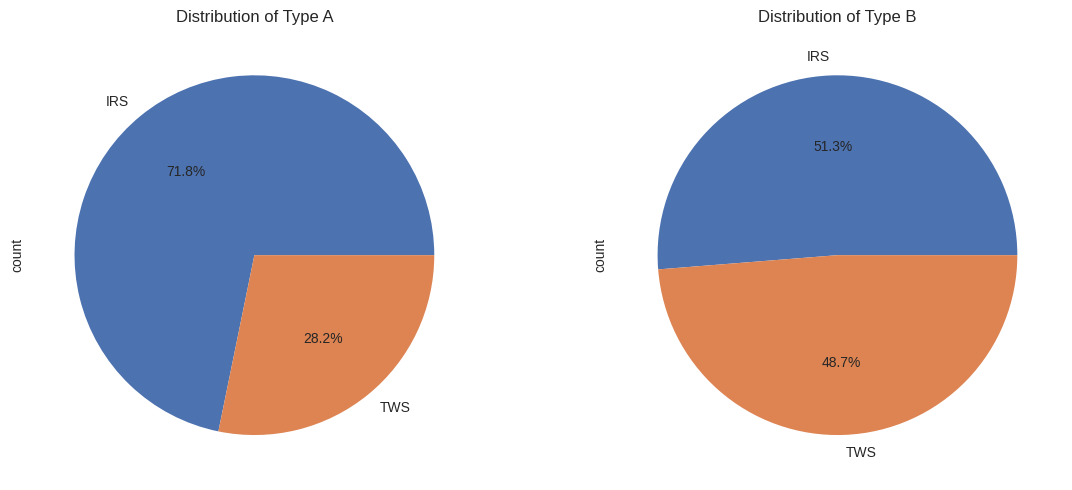

In [3]:
# Per-point machine analysis
print("\n===== Per-Point Machine Analysis =====")

# Count records per point machine
print("Counting records per point machine...")
point_counts = df[point_id_col].value_counts().sort_values(ascending=False)
print("\nRecord counts per point machine (top 10):")
display(point_counts.head(10))

plt.figure(figsize=(14, 6))
point_counts.head(20).plot(kind='bar')  # Show top 20 for visibility
plt.title('Number of Records per Point Machine (Top 20)')
plt.xlabel('Point Machine Name')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Analyze direction distributions
print("\nAnalyzing direction distributions...")
direction_by_machine = df.groupby(point_id_col)['Direction'].value_counts(normalize=True).unstack().fillna(0)
print("\nDirection distribution by point machine (first 10):")
display(direction_by_machine.head(10))

# Visualize direction distribution for top 10 machines by record count
top_machines = point_counts.head(10).index
print(f"\nVisualizing direction distribution for top {len(top_machines)} machines...")
plt.figure(figsize=(14, 7))
direction_subset = df[df[point_id_col].isin(top_machines)].copy()
sns.countplot(y=point_id_col, hue='Direction', data=direction_subset)
plt.title('Direction Distribution for Top 10 Point Machines')
plt.xlabel('Count')
plt.ylabel('Point Machine Name')
plt.tight_layout()
plt.show()

# Distribution of machine types
print("\nAnalyzing machine types...")
type_counts = pd.DataFrame({
    'Type A': df['Type of A'].value_counts(),
    'Type B': df['Type of B'].value_counts()
})
print("\nDistribution of point machine types:")
display(type_counts)

# Visualize type distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Type of A'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Distribution of Type A')
df['Type of B'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Distribution of Type B')
plt.tight_layout()
plt.show()

In [9]:
# Anomaly detection preparation
print("\n===== Anomaly Detection Preparation =====")

# Select numerical features for anomaly detection
numeric_features = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
print(f"Using electrical measurements as features: {numeric_features}")

# Prepare data for anomaly detection
X = df[numeric_features].copy()

# Check for data type issues
print("\nChecking data types in features:")
for col in tqdm(X.columns, desc="Checking column types"):
    print(f"{col}: {X[col].dtype}")
    # If column is not numeric, print a sample of non-numeric values
    if X[col].dtype == 'object':
        sample_non_numeric = X[col][~pd.to_numeric(X[col], errors='coerce').notna()].head(3).tolist()
        print(f"  Sample of non-numeric values: {sample_non_numeric}")

# Convert all columns to numeric (coercing errors to NaN)
for col in tqdm(X.columns, desc="Converting to numeric"):
    if X[col].dtype == 'object':
        print(f"Converting {col} from object to numeric")
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Check for and handle missing values
print(f"\nHandling {X.isna().sum().sum()} missing values in the features")
for col in tqdm(X.columns, desc="Handling missing values"):
    # Check if the column has all NaNs
    if X[col].isna().all():
        print(f"Warning: Column {col} has all NaN values. Dropping this column from analysis.")
        X = X.drop(columns=[col])
    else:
        # Use the median instead of mean as it's more robust to outliers
        X[col].fillna(X[col].median(), inplace=True)

# Check for and handle infinite values
inf_count = np.isinf(X).sum().sum()
if inf_count > 0:
    print(f"Found {inf_count} infinite values. Replacing with large finite values.")
    X = X.replace([np.inf, -np.inf], np.nan)
    # Fill NaNs (which were infs) with large values based on the sign
    for col in tqdm(X.columns, desc="Handling infinite values"):
        max_val = X[col].max() * 2  # Use 2x the max value as a reasonable substitute
        min_val = X[col].min() * 2  # Use 2x the min value as a reasonable substitute
        X[col].fillna(value=max_val if max_val > 0 else min_val, inplace=True)

# Verify no more NaNs or infinities remain
if X.isna().sum().sum() > 0:
    print(f"Warning: {X.isna().sum().sum()} NaN values remain. Filling with column means.")
    X = X.fillna(X.mean())

if np.isinf(X).sum().sum() > 0:
    print(f"Warning: Infinite values remain. Replacing with column means.")
    X = X.replace([np.inf, -np.inf], X.mean())

# Scale the features
print("\nScaling the features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check for NaNs or infs after scaling
if np.isnan(X_scaled).any() or np.isinf(X_scaled).any():
    print("Warning: NaNs or infinities found after scaling. Replacing with 0.")
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Method 1: Isolation Forest for anomaly detection
print("\nRunning Isolation Forest for anomaly detection...")
# Try a slightly higher contamination rate
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1) # Use all cores
with tqdm(total=100, desc="Isolation Forest") as pbar:
    pbar.update(10)  # Model initialization
    iso_forest.fit(X_scaled)
    pbar.update(40)  # Model fitting
    anomalies = iso_forest.predict(X_scaled)
    pbar.update(10)  # Prediction
    
    # Debug: Check if we actually have anomalies before mapping
    unique_values, counts = np.unique(anomalies, return_counts=True)
    print(f"Unique values in anomalies array: {unique_values}")
    print(f"Counts for each value: {counts}")
    
    # Directly set anomalies rather than using map which can fail silently
    df['anomaly_forest'] = np.where(anomalies == -1, 1, 0)  # 1 is anomaly, 0 is normal
    
    # Verify the count
    anomaly_count = df['anomaly_forest'].sum()
    print(f"Total Isolation Forest anomalies identified: {anomaly_count}")
    
    pbar.update(40)  # Mapping
# Method 2: Local Outlier Factor
print("Running Local Outlier Factor for anomaly detection...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
with tqdm(total=100, desc="Local Outlier Factor") as pbar:
    pbar.update(10)  # Model initialization
    # LOF combines fit and predict
    anomalies_lof = lof.fit_predict(X_scaled)
    pbar.update(80)  # Combined fit and predict
    df['anomaly_lof'] = anomalies_lof
    df['anomaly_lof'] = df['anomaly_lof'].map({1: 0, -1: 1})  # 1 is anomaly, 0 is normal
    pbar.update(10)  # Mapping

# Display anomaly detection results
print(f"\nIsolation Forest detected {df['anomaly_forest'].sum()} anomalies ({df['anomaly_forest'].mean()*100:.2f}% of data)")
print(f"LOF detected {df['anomaly_lof'].sum()} anomalies ({df['anomaly_lof'].mean()*100:.2f}% of data)")


===== Anomaly Detection Preparation =====
Using electrical measurements as features: ['A Current', 'A Voltage', 'B Current', 'B Voltage']

Checking data types in features:


Checking column types:   0%|          | 0/4 [00:00<?, ?it/s]

A Current: object
  Sample of non-numeric values: ['0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,1.8,1.9,2.1,2.3,2.6,2.8,3,3.2,3.4,3.5,3.7,3.7,3.7,3.5,3.4,3.2,3.1,2.9,2.6,2.5,2.3,0.0', '0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,1.9,2,2.1,2.2,2.3,2.3,2.3,2.2,2.1,1.9,1.8,1.7,1.7,1.6,1.2,0.5,0.0', '0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2.1,2.4,2.6,2.9,3.1,3.3,3.5,3.7,3.8,3.9,4,3.9,3.8,3.7,3.5,3.3,3.1,2.9,2.7,2.6,2.4,0.0']
A Voltage: object
  Sample of non-numeric values: ['0.0,13.5,46.5,72.0,88.5,99.0,103.5,108.0,109.5,111.0,111.0,112.5,112.5,112.5,111.0,109.5,108.0,105.0,105.0,102.0,102.0,100.5,100.5,99.0,99.0,100.5,102.0,103.5,103.5,105.0,106.5,108.0,109.5,0.0', '0.0,88.5,90.0,97.5,102.0,105.0,108.0,109.5,111.0,111.0,112.5,112.5,112.5,111.0,111.0,109.5,109.5,109.5,109.5,109.5,109.5,109.5,111.0,112.5,112.5,112.5,114.0,115.5,120.0,123.0,123.0,124.5,124.5,124.5,124.5,124.5,124.5,124.5,124.5,124.5,124.5,124.5,121.5,106.5,91.5,76.5,64.5,54.0,45.0,37.5,30.0,25.5,21.0,18.0,15.0,12.0

Converting to numeric:   0%|          | 0/4 [00:00<?, ?it/s]

Converting A Current from object to numeric
Converting A Voltage from object to numeric
Converting B Current from object to numeric
Converting B Voltage from object to numeric

Handling 1577450 missing values in the features


...

/tmp/ipykernel_247326/1645893173.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


Isolation Forest:   0%|          | 0/100 [00:00<?, ?it/s]

Unique values in anomalies array: [1]
Counts for each value: [394370]
Total Isolation Forest anomalies identified: 0
Running Local Outlier Factor for anomaly detection...


Local Outlier Factor:   0%|          | 0/100 [00:00<?, ?it/s]


Isolation Forest detected 0 anomalies (0.00% of data)
LOF detected 0 anomalies (0.00% of data)



===== Anomaly Visualization =====
Applying PCA...


PCA:   0%|          | 0/100 [00:00<?, ?it/s]

Explained variance ratio by PCA components: [nan nan]
Creating visualization sample...
Creating visualization plots...


/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


Plotting Isolation Forest:   0%|          | 0/100 [00:00<?, ?it/s]

Plotting LOF:   0%|          | 0/100 [00:00<?, ?it/s]

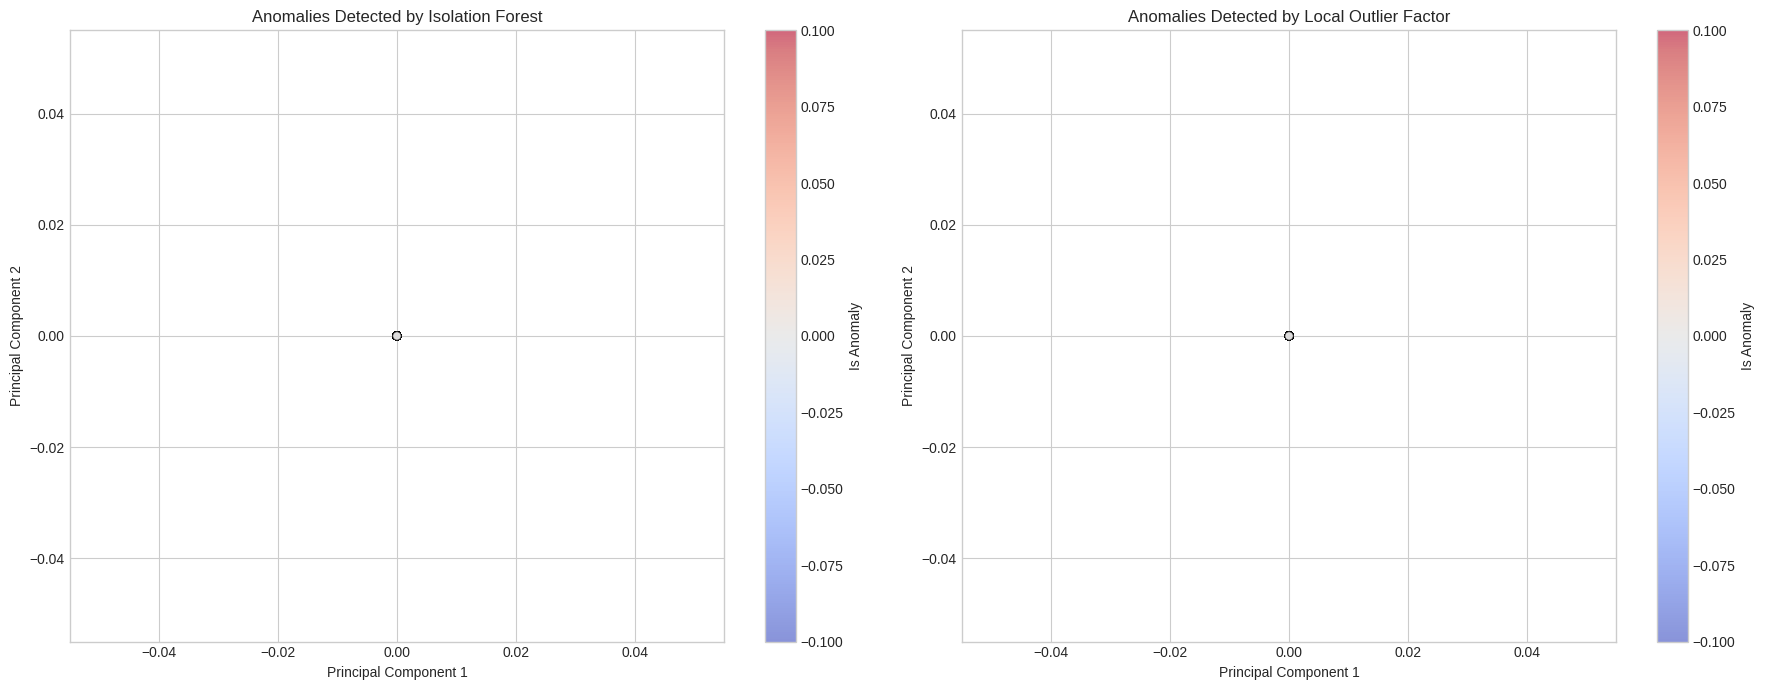

In [10]:
# Visualize anomalies in 2D space using PCA
print("\n===== Anomaly Visualization =====")

# Apply PCA to reduce to 2 dimensions for visualization
print("Applying PCA...")
pca = PCA(n_components=2)
with tqdm(total=100, desc="PCA") as pbar:
    X_pca = pca.fit_transform(X_scaled)
    pbar.update(100)
    
print(f"Explained variance ratio by PCA components: {pca.explained_variance_ratio_}")

# Create a sample for visualization (dataset is large)
print("Creating visualization sample...")
sample_size = min(5000, len(df))
sample_idx = np.random.choice(len(df), size=sample_size, replace=False)
X_pca_sample = X_pca[sample_idx]
forest_sample = df['anomaly_forest'].iloc[sample_idx]
lof_sample = df['anomaly_lof'].iloc[sample_idx]

# Plot anomalies using both methods
print("Creating visualization plots...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Isolation Forest results
with tqdm(total=100, desc="Plotting Isolation Forest") as pbar:
    scatter1 = axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=forest_sample, 
                            cmap='coolwarm', alpha=0.6, edgecolors='k', linewidths=0.5)
    pbar.update(50)
    axes[0].set_title('Anomalies Detected by Isolation Forest')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    plt.colorbar(scatter1, ax=axes[0], label='Is Anomaly')
    pbar.update(50)

# LOF results
with tqdm(total=100, desc="Plotting LOF") as pbar:
    scatter2 = axes[1].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=lof_sample, 
                            cmap='coolwarm', alpha=0.6, edgecolors='k', linewidths=0.5)
    pbar.update(50)
    axes[1].set_title('Anomalies Detected by Local Outlier Factor')
    axes[1].set_xlabel('Principal Component 1')
    axes[1].set_ylabel('Principal Component 2')
    plt.colorbar(scatter2, ax=axes[1], label='Is Anomaly')
    pbar.update(50)

plt.tight_layout()
plt.show()


===== Anomaly Distribution by Point Machine =====
Calculating anomaly rates per point machine...


Grouping by point machine:   0%|          | 0/100 [00:00<?, ?it/s]


Anomaly rates for point machines with at least 100 records (showing top 10):


,Isolation Forest Anomaly Rate,LOF Anomaly Rate,Record Count
Point Machine Name,,,
101/102,0.0,0.0,5384
PT107/108,0.0,0.0,1234
PT120,0.0,0.0,539
PT121,0.0,0.0,1781
PT121-122,0.0,0.0,1265
PT121/122,0.0,0.0,3296
PT122,0.0,0.0,364
PT123/124,0.0,0.0,2812
PT124,0.0,0.0,213


Creating anomaly rate visualization...


<Figure size 1600x800 with 0 Axes>

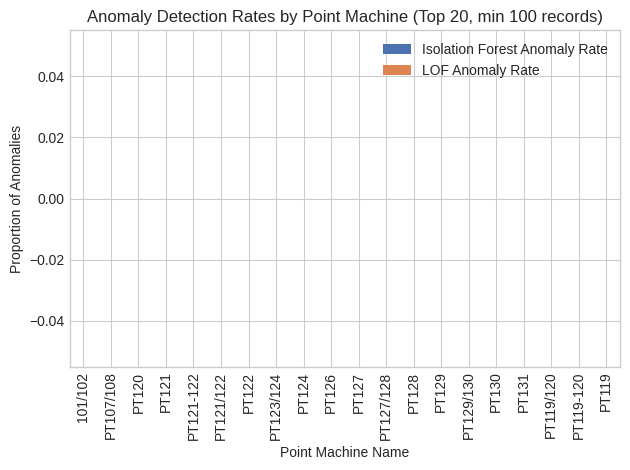


===== Detailed Analysis of Top 5 Anomalous Point Machines =====
Top 5 anomalous machines: ['101/102', 'PT107/108', 'PT120', 'PT121', 'PT121-122']


Analyzing top anomalous machines:   0%|          | 0/5 [00:00<?, ?it/s]


--- Analysis for 101/102 ---
Total records: 5384
Isolation Forest anomalies: 0 (0.00%)
LOF anomalies: 0 (0.00%)

Direction distribution:


Direction
Reverse    0.51133
Normal     0.48867
Name: proportion, dtype: float64


Machine type distribution:


,Type of A,Type of B
IRS,NaN,1.0
TWS,1.0,NaN


TypeError: can only concatenate str (not "int") to str

In [12]:
# Analyze anomaly distribution by point machine
print("\n===== Anomaly Distribution by Point Machine =====")

# Calculate anomaly rates per point machine
print("Calculating anomaly rates per point machine...")
point_id_col = 'Point Machine Name'  # Using the identified column

with tqdm(total=100, desc="Grouping by point machine") as pbar:
    anomaly_by_machine = df.groupby(point_id_col)[['anomaly_forest', 'anomaly_lof']].mean()
    pbar.update(50)
    anomaly_by_machine.columns = ['Isolation Forest Anomaly Rate', 'LOF Anomaly Rate']
    anomaly_by_machine['Record Count'] = df.groupby(point_id_col).size()
    pbar.update(50)

# Sort by anomaly rate and filter for better visualization
min_records = 100  # Minimum records needed for reliable analysis
filtered_anomalies = anomaly_by_machine[anomaly_by_machine['Record Count'] >= min_records].copy()
filtered_anomalies_sorted = filtered_anomalies.sort_values('Isolation Forest Anomaly Rate', ascending=False)

print(f"\nAnomaly rates for point machines with at least {min_records} records (showing top 10):")
display(filtered_anomalies_sorted.head(10))

# Visualize top 20 machines by anomaly rate
print("Creating anomaly rate visualization...")
plt.figure(figsize=(16, 8))
filtered_anomalies_sorted.head(20)[['Isolation Forest Anomaly Rate', 'LOF Anomaly Rate']].plot(kind='bar')
plt.title(f'Anomaly Detection Rates by Point Machine (Top 20, min {min_records} records)')
plt.xlabel('Point Machine Name')
plt.ylabel('Proportion of Anomalies')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Detailed analysis for top anomalous point machines
top_anomalous = filtered_anomalies_sorted.head(5).index.tolist()
print(f"\n===== Detailed Analysis of Top 5 Anomalous Point Machines =====")
print(f"Top 5 anomalous machines: {top_anomalous}")

for machine in tqdm(top_anomalous, desc="Analyzing top anomalous machines"):
    print(f"\n--- Analysis for {machine} ---")
    machine_data = df[df[point_id_col] == machine].copy()
    
    print(f"Total records: {len(machine_data)}")
    print(f"Isolation Forest anomalies: {machine_data['anomaly_forest'].sum()} ({machine_data['anomaly_forest'].mean()*100:.2f}%)")
    print(f"LOF anomalies: {machine_data['anomaly_lof'].sum()} ({machine_data['anomaly_lof'].mean()*100:.2f}%)")
    
    # Distribution of directions
    print("\nDirection distribution:")
    display(machine_data['Direction'].value_counts(normalize=True))
    
    # Type distributions
    print("\nMachine type distribution:")
    display(pd.DataFrame({
        'Type of A': machine_data['Type of A'].value_counts(normalize=True),
        'Type of B': machine_data['Type of B'].value_counts(normalize=True)
    }))
    
    # Feature statistics for this machine compared to overall
    comparison = pd.DataFrame({
        'Machine Mean': machine_data[numeric_features].mean(),
        'Overall Mean': df[numeric_features].mean(),
        'Machine STD': machine_data[numeric_features].std(),
        'Overall STD': df[numeric_features].std(),
    })
    
    # Calculate how many standard deviations this machine differs from overall
    comparison['Z-Score'] = abs((comparison['Machine Mean'] - comparison['Overall Mean']) / comparison['Overall STD'])
    
    print("\nFeature comparison (Z-scores show deviation from overall population):")
    display(comparison)
    
    # Visualize electrical feature distributions
    print("\nCreating feature distribution plots...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Feature Distributions for {machine}', fontsize=16)
    
    for i, feature in enumerate(numeric_features):
        row, col = divmod(i, 2)
        # Machine data
        sns.histplot(machine_data[feature], kde=True, ax=axes[row, col], color='red', alpha=0.5, label=machine)
        # Random sample from other machines for comparison
        other_machines = df[df[point_id_col] != machine].sample(min(len(machine_data)*2, 10000))
        sns.histplot(other_machines[feature], kde=True, ax=axes[row, col], color='blue', alpha=0.3, label='Other Machines')
        
        # Add vertical line for overall mean
        axes[row, col].axvline(df[feature].mean(), color='black', linestyle='--', label='Overall Mean')
        
        axes[row, col].set_title(f'{feature} Distribution')
        axes[row, col].legend()
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()